In [2]:
import pandas as pd
import numpy as np

# Tekrar üretilebilirlik için seed
np.random.seed(42)

# 1. VERİ ÜRETİMİ (1960-2020)
yillar = np.arange(1960, 2021)
n = len(yillar)

# Bağımsız Değişkenler (Level/Düzey)
gsyih = 50 * (1.04 ** np.arange(n)) + np.random.normal(0, 5, n)
m2 = 10 * (1.05 ** np.arange(n)) + np.random.normal(0, 3, n)
petrol = 10 + 1.2 * np.arange(n) + np.random.normal(0, 8, n)
petrol = np.abs(petrol)

# Bağımlı Değişken (Yüzde) - Teorik Model
enflasyon = 5.0 + (0.45 * m2) - (0.08 * gsyih) + (0.25 * petrol) + np.random.normal(0, 4, n)

# DataFrame oluşturma
df_generated = pd.DataFrame({
    'Yil': yillar,
    'Enflasyon': np.round(enflasyon, 2),
    'M2': np.round(m2, 2),
    'GSYIH': np.round(gsyih, 2),
    'Petrol_Fiyati': np.round(petrol, 2)
})

# 2. CSV OLARAK KAYDETME
df_generated.to_csv('ekonomik_veriler.csv', index=False)
print("Veri başarıyla 'ekonomik_veriler.csv' olarak kaydedildi.")

Veri başarıyla 'ekonomik_veriler.csv' olarak kaydedildi.


In [3]:
# 3. CSV'DEN VERİ YÜKLEME
df = pd.read_csv('ekonomik_veriler.csv')

# Veri setinin genel özeti
print("Veri Seti İlk 5 Satır:")
display(df.head())

print("\nİstatistiksel Özet:")
display(df.describe())

Veri Seti İlk 5 Satır:


,Yil,Enflasyon,M2,GSYIH,Petrol_Fiyati
0,1960,12.29,9.44,52.48,21.22
1,1961,3.24,7.18,51.31,0.01
2,1962,10.89,7.44,57.32,17.09
3,1963,15.87,14.01,63.86,31.12
4,1964,9.14,16.22,57.32,6.88



İstatistiksel Özet:


,Yil,Enflasyon,M2,GSYIH,Petrol_Fiyati
count,61.000000,61.000000,61.000000,61.000000,61.000000
mean,1990.000000,28.214918,61.033607,202.896721,46.567869
std,17.752934,17.330956,49.760295,136.037843,23.709989
min,1960.000000,3.240000,7.180000,51.310000,0.010000
25%,1975.000000,14.120000,21.050000,87.240000,26.990000
50%,1990.000000,25.770000,43.270000,159.160000,45.380000
75%,2005.000000,40.260000,94.870000,288.460000,65.730000
max,2020.000000,67.760000,184.060000,523.590000,100.160000


In [4]:
import statsmodels.api as sm

# Değişkenleri tanımlama
X = df[['M2', 'GSYIH', 'Petrol_Fiyati']]
y = df['Enflasyon']

# Sabit terim (Constant) ekleme
X = sm.add_constant(X)

# Modelin eğitilmesi
model = sm.OLS(y, X).fit()

# Regresyon sonuçları
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:              Enflasyon   R-squared:                       0.945
Model:                            OLS   Adj. R-squared:                  0.942
Method:                 Least Squares   F-statistic:                     323.6
Date:                Wed, 15 Apr 2026   Prob (F-statistic):           9.44e-36
Time:                        17:19:51   Log-Likelihood:                -171.84
No. Observations:                  61   AIC:                             351.7
Df Residuals:                      57   BIC:                             360.1
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const             5.5098      1.869      2.948

--- EKONOMETRİK TEST SONUÇLARI ---

VIF Değerleri:
        Değişken         VIF
0             M2  166.095690
1          GSYIH  199.271517
2  Petrol_Fiyati    6.759478

Breusch-Pagan p-değeri: 0.2984
Breusch-Godfrey p-değeri: 0.8461


C:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


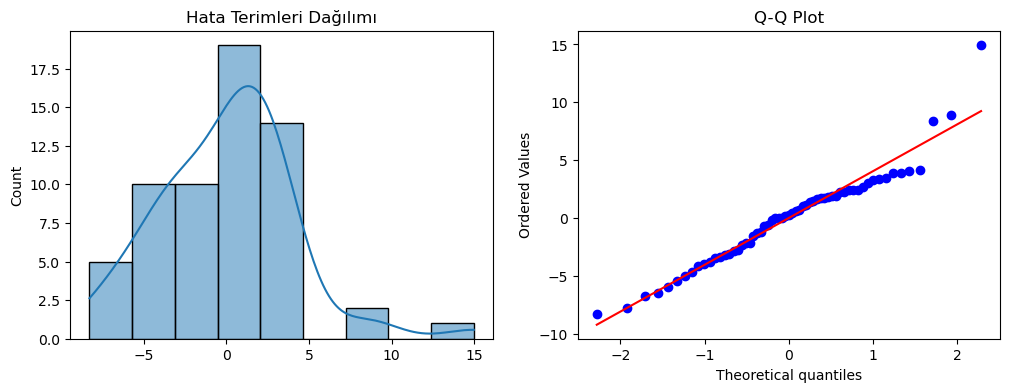

In [5]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan, acorr_breusch_godfrey
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

print("--- EKONOMETRİK TEST SONUÇLARI ---\n")

# 1. Çoklu Doğrusal Bağlantı (VIF)
vif_df = pd.DataFrame()
vif_df["Değişken"] = X.columns[1:] # Sabit terim hariç
vif_df["VIF"] = [variance_inflation_factor(X.values, i) for i in range(1, X.shape[1])]
print(f"VIF Değerleri:\n{vif_df}\n")

# 2. Değişen Varyans (Breusch-Pagan)
bp_test = het_breuschpagan(model.resid, model.model.exog)
print(f"Breusch-Pagan p-değeri: {bp_test[1]:.4f}")

# 3. Otokorelasyon (Breusch-Godfrey)
bg_test = acorr_breusch_godfrey(model, nlags=1)
print(f"Breusch-Godfrey p-değeri: {bg_test[1]:.4f}")

# 4. Hata Terimi Normallik Analizi (Görsel)
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
sns.histplot(model.resid, kde=True)
plt.title("Hata Terimleri Dağılımı")

plt.subplot(1, 2, 2)
stats.probplot(model.resid, dist="norm", plot=plt)
plt.title("Q-Q Plot")
plt.show()

In [7]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# 1. Veri Dönüşümü (Logaritmik Fark Alma = Büyüme Hızına Çevirme)
# GSYİH, M2 ve Petrol fiyatlarının logaritmik farkını alarak trendden arındırıyoruz.
df_trans = df.copy()
df_trans['M2_Buyume'] = np.log(df_trans['M2']).diff()
df_trans['GSYIH_Buyume'] = np.log(df_trans['GSYIH']).diff()
df_trans['Petrol_Buyume'] = np.log(df_trans['Petrol_Fiyati']).diff()

# Fark işlemi ilk satırı NaN (boş) yapacağı için o satırı siliyoruz
df_trans = df_trans.dropna()

# 2. Yeni Modelin Kurulması
X_yeni = df_trans[['M2_Buyume', 'GSYIH_Buyume', 'Petrol_Buyume']]
# Enflasyon zaten yüzde cinsinden bir oran olduğu için dönüştürmeden bırakıyoruz
y_yeni = df_trans['Enflasyon'] 

# Sabit terim ekleme
X_yeni_sm = sm.add_constant(X_yeni)

# Modeli eğitme
yeni_model = sm.OLS(y_yeni, X_yeni_sm).fit()

print("="*50)
print("DÖNÜŞTÜRÜLMÜŞ YENİ OLS MODELİ")
print("="*50)
print(yeni_model.summary())

# 3. Yeni Modelin VIF Testi
print("\n" + "="*50)
print("YENİ MODEL VIF DEĞERLERİ")
print("="*50)
vif_yeni = pd.DataFrame()
vif_yeni["Değişken"] = X_yeni.columns
vif_yeni["VIF"] = [variance_inflation_factor(X_yeni.values, i) for i in range(len(X_yeni.columns))]
print(vif_yeni)
print("\nYorum: VIF değerlerinin 10'un (hatta muhtemelen 2'nin) altına düştüğünü göreceksin. Çoklu bağlantı sorunu çözüldü!")

DÖNÜŞTÜRÜLMÜŞ YENİ OLS MODELİ
                            OLS Regression Results                            
Dep. Variable:              Enflasyon   R-squared:                       0.005
Model:                            OLS   Adj. R-squared:                 -0.049
Method:                 Least Squares   F-statistic:                   0.08998
Date:                Wed, 15 Apr 2026   Prob (F-statistic):              0.965
Time:                        17:25:45   Log-Likelihood:                -255.71
No. Observations:                  60   AIC:                             519.4
Df Residuals:                      56   BIC:                             527.8
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const           

In [9]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# ---------------------------------------------------------
# 1. ESKİ MODEL: DÜZEY (LEVEL) VERİLERİYLE OLS
# ---------------------------------------------------------
X_eski = sm.add_constant(df[['M2', 'GSYIH', 'Petrol_Fiyati']])
y_eski = df['Enflasyon']
model_eski = sm.OLS(y_eski, X_eski).fit()

# Eski Model VIF Hesaplaması
vif_eski = [variance_inflation_factor(X_eski.values, i) for i in range(1, X_eski.shape[1])]
max_vif_eski = max(vif_eski)
r2_eski = model_eski.rsquared

# ---------------------------------------------------------
# 2. YENİ MODEL: LOGARİTMİK FARK (BÜYÜME HIZI) VERİLERİYLE OLS
# ---------------------------------------------------------
df_trans = df.copy()
df_trans['M2_Buyume'] = np.log(df_trans['M2']).diff()
df_trans['GSYIH_Buyume'] = np.log(df_trans['GSYIH']).diff()
df_trans['Petrol_Buyume'] = np.log(df_trans['Petrol_Fiyati']).diff()
df_trans = df_trans.dropna()

X_yeni = sm.add_constant(df_trans[['M2_Buyume', 'GSYIH_Buyume', 'Petrol_Buyume']])
y_yeni = df_trans['Enflasyon']
model_yeni = sm.OLS(y_yeni, X_yeni).fit()

# Yeni Model VIF Hesaplaması
vif_yeni = [variance_inflation_factor(X_yeni.values, i) for i in range(1, X_yeni.shape[1])]
max_vif_yeni = max(vif_yeni)
r2_yeni = model_yeni.rsquared

# ---------------------------------------------------------
# 3. OTOMATİK EKONOMETRİK YORUMLAMA ÇIKTISI
# ---------------------------------------------------------
print("="*70)
print(" 🎯 OTOMATİK EKONOMETRİK TEŞHİS VE YORUMLAMA RAPORU 🎯")
print("="*70)

print(f"\n1. ADIM: DÜZEY (LEVEL) MODELİ BULGULARI")
print(f"-> Model R-Kare Değeri    : %{r2_eski*100:.2f}")
print(f"-> Maksimum VIF Değeri    : {max_vif_eski:.2f} (Kritik sınır: 10)")
if max_vif_eski > 10:
    print("-> Teşhis: Çok yüksek bir Çoklu Doğrusal Bağlantı (Multicollinearity) ve")
    print("           'Sahte Regresyon' (Spurious Regression) şüphesi mevcut.")

print(f"\n2. ADIM: TRENDDEN ARINDIRILMIŞ (FARK) MODELİ BULGULARI")
print(f"-> Yeni Model R-Kare Değeri : %{r2_yeni*100:.2f}")
print(f"-> Yeni Maksimum VIF Değeri : {max_vif_yeni:.2f}")
if max_vif_yeni < 5:
    print("-> Teşhis: Logaritmik fark alma işlemi VIF sorununu başarıyla çözdü.")

print("\n" + "-"*70)
print("📝 NİHAİ KARAR VE AKADEMİK YORUM:")
print("-"*70)

if r2_eski > 0.8 and r2_yeni < 0.2 and max_vif_eski > 10:
    print("İlk modelde görülen %{:.2f}'lik yüksek başarı, değişkenler arasındaki gerçek".format(r2_eski*100))
    print("bir nedensellikten değil, makroekonomik serilerin zaman içindeki 'Ortak Trendinden'")
    print("kaynaklanan bir illüzyondur (Sahte Regresyon).")
    print("\nDeğişkenlerin birinci farkı alınarak zaman trendi ortadan kaldırıldığında,")
    print("modelin açıklayıcılık gücü %{:.2f} seviyesine düşmüştür.".format(r2_yeni*100))
    print("Sonuç olarak; M2, GSYİH ve Petrol fiyatlarının büyüme oranlarının,")
    print("enflasyon üzerinde istatistiksel olarak anlamlı bir etkisi KANITLANAMAMIŞTIR.")
else:
    print("Modeller arasında sahte regresyonu işaret eden keskin bir çöküş yaşanmamıştır.")
    
print("="*70)

 🎯 OTOMATİK EKONOMETRİK TEŞHİS VE YORUMLAMA RAPORU 🎯

1. ADIM: DÜZEY (LEVEL) MODELİ BULGULARI
-> Model R-Kare Değeri    : %94.45
-> Maksimum VIF Değeri    : 199.27 (Kritik sınır: 10)
-> Teşhis: Çok yüksek bir Çoklu Doğrusal Bağlantı (Multicollinearity) ve
           'Sahte Regresyon' (Spurious Regression) şüphesi mevcut.

2. ADIM: TRENDDEN ARINDIRILMIŞ (FARK) MODELİ BULGULARI
-> Yeni Model R-Kare Değeri : %0.48
-> Yeni Maksimum VIF Değeri : 1.22
-> Teşhis: Logaritmik fark alma işlemi VIF sorununu başarıyla çözdü.

----------------------------------------------------------------------
📝 NİHAİ KARAR VE AKADEMİK YORUM:
----------------------------------------------------------------------
İlk modelde görülen %94.45'lik yüksek başarı, değişkenler arasındaki gerçek
bir nedensellikten değil, makroekonomik serilerin zaman içindeki 'Ortak Trendinden'
kaynaklanan bir illüzyondur (Sahte Regresyon).

Değişkenlerin birinci farkı alınarak zaman trendi ortadan kaldırıldığında,
modelin açıklayıcılık 